# Diagnóstico de series temporales — Municipio C

**Proyecto de Aprendizaje Automático (PAA) — UTEC / LIDIA 2026 · Predicción de siniestros viales**

Complementa [`diagnostico_datos.ipynb`](diagnostico_datos.ipynb) (diagnóstico de calidad,
cobertura, adecuación y limitaciones de los ocho municipios) con un análisis que ese notebook
**no hace**: la estructura temporal — tendencia, estacionalidad, autocorrelación (ACF/PACF) y
dispersión por rezago — de la serie diaria de siniestros de un único municipio, y la decisión,
apoyada en esa evidencia, de si corresponde diferenciar o transformar (logaritmo/Box-Cox) el
objetivo antes de modelarlo.

**Alcance: Municipio C, 2021-07-01 a 2025-12-31.** Municipio C se eligió por ser el que más
siniestros concentra de los ocho (5.783, **15,80 %** del total; `resumen_diagnostico_datos.md`,
§4.2) — la serie con más soporte para ver estructura temporal sin que la ruidosa varianza de
Poisson de una serie de conteo bajo la tape (`resumen_diagnostico_datos.md`, §5.2). El recorte
territorial y temporal (Montevideo, municipios, desde 2021-07-01) **se hereda tal cual** del
diagnóstico principal: esa decisión ya está justificada con evidencia allí (§2.6 y §3.1 de este
notebook reproducen el recorte, no lo vuelven a discutir).

**Qué responde este notebook**

| Pregunta | Sección |
| --- | --- |
| ¿Hay tendencia, y estacionalidad diaria/semanal/anual, en la serie de un municipio? | 2 |
| ¿Qué dice la ACF/PACF sobre la persistencia de la serie y su relación con el calendario? | 3 |
| ¿La dispersión entre un día y sus rezagos sugiere memoria del proceso? | 3.4 |
| ¿Corresponde diferenciar la serie o aplicar una transformación log/Box-Cox? | 4 |

**Qué NO hace.** No repite el diagnóstico de calidad, cobertura ni adecuación de
`diagnostico_datos.ipynb` — se remite a él. No decide el modelo final: alimenta esa decisión con
evidencia sobre la estructura temporal de una serie de conteo bajo.

**Fuentes.** Sólo el CSV de siniestros y la capa de municipios (no hace falta el clima para este
análisis). La asignación punto-polígono se reimplementa aquí con `geopandas` — una librería
distinta de la que usa `diagnostico_datos.ipynb` (que arma sus propios polígonos con
`matplotlib.path` para no depender de ninguna librería geoespacial) — precisamente para que la
coincidencia de resultados (sección 1.3) sea una **verificación independiente**, no una
reejecución del mismo código.

**Artefactos.** Tablas y figuras en `experiments/diagnostico_datos_municipio/`.

## 0. Configuración y trazabilidad

In [1]:
import hashlib
import platform
import sys
from datetime import datetime, timezone
from pathlib import Path

import geopandas as gpd
import holidays
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from pyproj import Transformer
from scipy import stats as sps
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import acf, adfuller, kpss, pacf

RAIZ = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "data" / "raw").is_dir())
DIR_CRUDO = RAIZ / "data" / "raw"
RUTA_CSV = DIR_CRUDO / "uru_siniestros_unificado.csv"
RUTA_ZONAS = DIR_CRUDO / "municipios_montevideo.geojson"

DIR_SALIDA = RAIZ / "experiments" / "diagnostico_datos_municipio"
DIR_TABLAS = DIR_SALIDA / "tablas"
DIR_FIGURAS = DIR_SALIDA / "figuras"
for d in (DIR_TABLAS, DIR_FIGURAS):
    d.mkdir(parents=True, exist_ok=True)

# Alcance heredado de diagnostico_datos.ipynb (secciones 2.6 y 3.1 de ese notebook).
# No se vuelve a justificar acá: cambiar estas constantes sin releer esa evidencia invalida
# la comparación con resumen_diagnostico_datos.md que hace la sección 1.3.
DEPARTAMENTO = "MONTEVIDEO"
FECHA_INICIO = "2021-07-01"
MUNICIPIO_FOCO = "C"
CATEGORIAS_FERIADO = ("public", "bank")
CRS_ORIGEN, CRS_DESTINO = "EPSG:32721", "EPSG:4326"

pd.set_option("display.width", 130)
plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 140, "savefig.bbox": "tight",
    "axes.grid": True, "grid.alpha": 0.25, "axes.spines.top": False,
    "axes.spines.right": False, "font.size": 9,
})


def guardar_tabla(tabla, nombre, indice=False):
    destino = DIR_TABLAS / f"{nombre}.csv"
    tabla.to_csv(destino, index=indice, encoding="utf-8")
    print(f"[tabla]  {destino.relative_to(RAIZ)}")
    display(tabla)


def guardar_figura(fig, nombre):
    destino = DIR_FIGURAS / f"{nombre}.png"
    fig.savefig(destino)
    print(f"[figura] {destino.relative_to(RAIZ)}")

La capa de municipios se volvió a descargar el día de esta ejecución (misma consulta WFS que usa
`diagnostico_datos.ipynb`, sección 2.6: GeoServer de la Intendencia,
`mapstore-tematicas:zon_v_sig_municipios`, `GetFeature` en GeoJSON). Su contenido no cambia
(son límites municipales oficiales), pero el `sha256` de una respuesta WFS recién pedida al
servidor no tiene por qué coincidir byte a byte con el de una descarga anterior — por eso se
registra su **propia** procedencia en vez de asumir la del otro notebook.

In [2]:
FUENTES = [("siniestros", RUTA_CSV), ("municipios", RUTA_ZONAS)]
filas = []
for nombre, ruta in FUENTES:
    if not ruta.exists():
        filas.append((nombre, str(ruta.relative_to(RAIZ)), "AUSENTE", "", ""))
        continue
    filas.append((
        nombre, str(ruta.relative_to(RAIZ)), f"{ruta.stat().st_size / 1e6:.2f} MB",
        hashlib.sha256(ruta.read_bytes()).hexdigest(),
        datetime.fromtimestamp(ruta.stat().st_mtime).strftime("%Y-%m-%d %H:%M"),
    ))
procedencia = pd.DataFrame(filas, columns=["fuente", "archivo", "tamaño", "sha256", "modificado"])

paquetes = ["pandas", "numpy", "geopandas", "statsmodels", "scipy", "matplotlib", "holidays"]
import importlib.metadata as md_meta
entorno = pd.DataFrame(
    [("ejecutado", datetime.now(timezone.utc).astimezone().strftime("%Y-%m-%d %H:%M")),
     ("python", f"{sys.version.split()[0]} · {platform.system()} {platform.release()}"),
     ("municipio analizado", MUNICIPIO_FOCO)]
    + [(p, md_meta.version(p)) for p in paquetes], columns=["clave", "valor"])

guardar_tabla(procedencia, "00_procedencia")
guardar_tabla(entorno, "00b_entorno")

[tabla]  experiments\diagnostico_datos_municipio\tablas\00_procedencia.csv


,fuente,archivo,tamaño,sha256,modificado
0,siniestros,data\raw\uru_siniestros_unificado.csv,26.19 MB,48a8a7e8f06ed8aa1d138b9921995d81a2c86cb3858354...,2026-08-24 07:21
1,municipios,data\raw\municipios_montevideo.geojson,2.87 MB,ed0ba13e53b08f1e35eead16ffdef16d57e518aff30c7c...,2026-09-07 09:36


[tabla]  experiments\diagnostico_datos_municipio\tablas\00b_entorno.csv


,clave,valor
0,ejecutado,2026-09-20 16:52
1,python,3.13.15 · Windows 11
2,municipio analizado,C
3,pandas,2.3.3
4,numpy,2.5.2
5,geopandas,1.1.4
6,statsmodels,0.14.6
7,scipy,1.18.1
8,matplotlib,3.11.1
9,holidays,0.103


## 1. Recorte, asignación a municipios y verificación cruzada

### 1.1 Recorte al alcance ya fijado

Mismo recorte que `diagnostico_datos.ipynb` (Montevideo, desde 2021-07-01, duplicados exactos
eliminados). No se vuelve a justificar la fecha de inicio ni la unidad territorial: esa evidencia
está en las secciones 2.6 y 3.1 de ese notebook.

In [3]:
df_pais = pd.read_csv(RUTA_CSV, skipinitialspace=True, encoding="utf-8")
df_pais.columns = df_pais.columns.str.strip()
df_pais["Fecha"] = pd.to_datetime(df_pais["Fecha"], format="%m/%d/%Y")
for c in df_pais.select_dtypes(include=["object", "string"]).columns:
    # astype(str) convierte NaN en el texto "nan" (pandas 2.x); .where restituye el nulo.
    df_pais[c] = df_pais[c].astype(str).str.strip().where(df_pais[c].notna())

pasos = [("registros del archivo", len(df_pais))]
sel = df_pais[df_pais["Departamento"] == DEPARTAMENTO]
pasos.append((f"tras filtrar {DEPARTAMENTO}", len(sel)))
sel = sel[sel["Fecha"] >= pd.Timestamp(FECHA_INICIO)]
pasos.append((f"tras filtrar fecha >= {FECHA_INICIO}", len(sel)))

df = sel.copy().reset_index(drop=True)
dedup = df.drop_duplicates(keep="first").reset_index(drop=True)
pasos.append(("tras eliminar duplicados exactos", len(dedup)))

recorte = pd.DataFrame(pasos, columns=["paso", "registros"])
recorte["pct_del_archivo"] = (100 * recorte["registros"] / len(df_pais)).round(2)
guardar_tabla(recorte, "01_recorte_alcance")

FECHA_FIN = dedup["Fecha"].max()
DIAS = pd.date_range(FECHA_INICIO, FECHA_FIN, freq="D")
print(f"período: {DIAS[0]:%Y-%m-%d} -> {DIAS[-1]:%Y-%m-%d}  ({len(DIAS):,} días)")

[tabla]  experiments\diagnostico_datos_municipio\tablas\01_recorte_alcance.csv


,paso,registros,pct_del_archivo
0,registros del archivo,224694,100.00
1,tras filtrar MONTEVIDEO,62427,27.78
2,tras filtrar fecha >= 2021-07-01,36713,16.34
3,tras eliminar duplicados exactos,36623,16.30


período: 2021-07-01 -> 2025-12-31  (1,645 días)


### 1.2 Asignación punto-polígono a municipios

Intersección punto-polígono entre las coordenadas UTM de cada siniestro (reproyectadas a
`EPSG:4326`) y la capa de municipios, con `geopandas.sjoin`. Los siniestros que no caen en ningún
polígono se descartan, igual que en `diagnostico_datos.ipynb` (§2.6): son un puñado de puntos de
borde, no se reasignan al municipio más cercano para no introducir una decisión arbitraria.

In [4]:
gdf_zonas = gpd.read_file(RUTA_ZONAS).to_crs(CRS_DESTINO)
NOMBRE_COL = next(c for c in ["municipio", "MUNICIPIO", "nombre", "NOMBRE"] if c in gdf_zonas.columns)
print(f"capa: {RUTA_ZONAS.name} · {len(gdf_zonas)} polígonos · municipios: "
      f"{', '.join(sorted(gdf_zonas[NOMBRE_COL].astype(str)))}")

transformador = Transformer.from_crs(CRS_ORIGEN, CRS_DESTINO, always_xy=True)
lon, lat = transformador.transform(dedup["X"].to_numpy(float), dedup["Y"].to_numpy(float))
puntos = gpd.GeoDataFrame(
    dedup[["Fecha"]].copy(), geometry=gpd.points_from_xy(lon, lat), crs=CRS_DESTINO
)

asignado = gpd.sjoin(puntos, gdf_zonas[[NOMBRE_COL, "geometry"]], how="left", predicate="within")
asignado = asignado.rename(columns={NOMBRE_COL: "municipio"})
sin_municipio = asignado["municipio"].isna()

conteo_municipios = (
    asignado.loc[~sin_municipio, "municipio"].value_counts()
    .rename_axis("municipio").reset_index(name="siniestros")
)
conteo_municipios["pct_del_total"] = (
    100 * conteo_municipios["siniestros"] / (~sin_municipio).sum()
).round(2)
guardar_tabla(conteo_municipios, "02_asignacion_municipios")

print(f"fuera de todo polígono: {int(sin_municipio.sum())} "
      f"({100 * sin_municipio.mean():.2f} % del recorte deduplicado)")

capa: municipios_montevideo.geojson · 8 polígonos · municipios: A, B, C, CH, D, E, F, G
[tabla]  experiments\diagnostico_datos_municipio\tablas\02_asignacion_municipios.csv


,municipio,siniestros,pct_del_total
0,C,5783,15.80
1,B,5377,14.69
2,D,5319,14.53
3,A,5016,13.70
4,F,4424,12.08
5,G,3701,10.11
6,E,3615,9.87
7,CH,3377,9.22


fuera de todo polígono: 11 (0.03 % del recorte deduplicado)


### 1.3 Verificación cruzada con `resumen_diagnostico_datos.md`

`diagnostico_datos.ipynb` asigna municipios con su propia implementación (polígonos armados a
mano con `matplotlib.path`, sin ninguna dependencia geoespacial). Este notebook usa `geopandas`.
Si las dos coinciden, son dos implementaciones independientes llegando al mismo número — la misma
lógica de verificación cruzada que ese notebook aplica contra el ETL (su sección 7).

In [5]:
REFERENCIA_MUNICIPIOS = {
    "C": 5783, "B": 5377, "D": 5319, "A": 5016,
    "F": 4424, "G": 3701, "E": 3615, "CH": 3377,
}
verificacion = conteo_municipios.set_index("municipio")["siniestros"].to_dict()
comparacion = pd.DataFrame(
    [(m, REFERENCIA_MUNICIPIOS.get(m), verificacion.get(m),
      "coincide" if REFERENCIA_MUNICIPIOS.get(m) == verificacion.get(m) else "DIFIERE")
     for m in sorted(set(REFERENCIA_MUNICIPIOS) | set(verificacion))],
    columns=["municipio", "resumen_diagnostico_datos.md (§4.2)", "recalculado acá (geopandas)", "resultado"],
)
guardar_tabla(comparacion, "03_verificacion_cruzada")
assert (comparacion["resultado"] == "coincide").all(), "la reasignación con geopandas no coincide con el diagnóstico principal"
print("Las ocho cifras coinciden: la asignación con geopandas reproduce la de diagnostico_datos.ipynb.")

[tabla]  experiments\diagnostico_datos_municipio\tablas\03_verificacion_cruzada.csv


,municipio,resumen_diagnostico_datos.md (§4.2),recalculado acá (geopandas),resultado
0,A,5016,5016,coincide
1,B,5377,5377,coincide
2,C,5783,5783,coincide
3,CH,3377,3377,coincide
4,D,5319,5319,coincide
5,E,3615,3615,coincide
6,F,4424,4424,coincide
7,G,3701,3701,coincide


Las ocho cifras coinciden: la asignación con geopandas reproduce la de diagnostico_datos.ipynb.


### 1.4 La serie diaria de Municipio C

Se reindexa contra el calendario completo del período (`DIAS`), rellenando con 0 los días sin
siniestros en ese municipio — no hay huecos de calendario que tratar (`diagnostico_datos.ipynb`,
§3.5: la serie del departamento no tiene ningún día vacío).

In [6]:
c = asignado.loc[asignado["municipio"] == MUNICIPIO_FOCO]
serie_c = c.groupby("Fecha").size().reindex(DIAS, fill_value=0).rename("n_siniestros")
serie_c.index.name = "fecha"

media, varianza = serie_c.mean(), serie_c.var(ddof=0)
resumen_serie = pd.DataFrame(
    [("municipio", MUNICIPIO_FOCO),
     ("días del período", len(DIAS)),
     ("siniestros totales", int(serie_c.sum())),
     ("días en cero", int((serie_c == 0).sum())),
     ("% de días en cero", round(100 * (serie_c == 0).mean(), 2)),
     ("media diaria", round(media, 4)),
     ("varianza diaria (ddof=0)", round(varianza, 4)),
     ("índice de dispersión (var/media)", round(varianza / media, 4)),
     ("máximo diario", int(serie_c.max())),
     ("mediana diaria", float(serie_c.median()))],
    columns=["indicador", "valor"],
)
guardar_tabla(resumen_serie, "04_resumen_serie_municipio_c")

[tabla]  experiments\diagnostico_datos_municipio\tablas\04_resumen_serie_municipio_c.csv


,indicador,valor
0,municipio,C
1,días del período,1645
2,siniestros totales,5783
3,días en cero,79
4,% de días en cero,4.8
5,media diaria,3.5155
6,varianza diaria (ddof=0),4.4297
7,índice de dispersión (var/media),1.26
8,máximo diario,13
9,mediana diaria,3.0


**Evidencia:** la serie de Municipio C hereda la sobredispersión leve del panel completo
(var/media ≈ 1,26 tanto acá como en `resumen_diagnostico_datos.md` §5.1) y tiene bastante menos
ceros que el panel agregado por municipio (8,60 % en el panel de las ocho zonas) porque es,
precisamente, la zona con más actividad. Con media diaria de algo más de tres siniestros y menos
de 5 % de días en cero, la serie tiene soporte suficiente para las cuatro figuras exploratorias
de la sección siguiente sin que el ruido de una tasa muy baja las vuelva ilegibles — la razón por
la que se eligió este municipio y no uno de los de menor actividad.

## 2. Gráficos exploratorios: tendencia y estacionalidad

### 2.1 Tendencia

Serie diaria cruda con medias móviles de 30 y 90 días, y la media anual (el 2021 sólo aporta
julio-diciembre, igual que en el resto del diagnóstico).

[figura] experiments\diagnostico_datos_municipio\figuras\fig1_tendencia_municipio_c.png


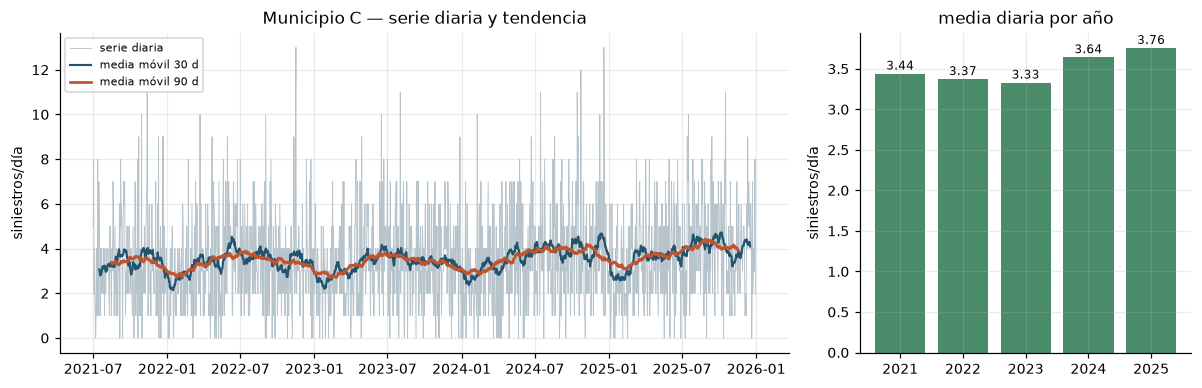

[tabla]  experiments\diagnostico_datos_municipio\tablas\05_tendencia_anual.csv


,año,media_diaria
0,2021,3.4402
1,2022,3.3726
2,2023,3.3288
3,2024,3.6421
4,2025,3.7562


In [7]:
media_movil_30 = serie_c.rolling(30, center=True).mean()
media_movil_90 = serie_c.rolling(90, center=True).mean()
media_anual = serie_c.groupby(serie_c.index.year).mean()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.6), gridspec_kw={"width_ratios": [2.2, 1]})

ax1.plot(serie_c.index, serie_c.values, color="#b8c4cc", lw=0.6, label="serie diaria")
ax1.plot(media_movil_30.index, media_movil_30.values, color="#22546e", lw=1.4, label="media móvil 30 d")
ax1.plot(media_movil_90.index, media_movil_90.values, color="#c0542f", lw=1.8, label="media móvil 90 d")
ax1.set_title(f"Municipio {MUNICIPIO_FOCO} — serie diaria y tendencia")
ax1.set_ylabel("siniestros/día"); ax1.legend(fontsize=7, loc="upper left")

ax2.bar(media_anual.index.astype(str), media_anual.values, color="#4a8c6a")
for x, v in zip(media_anual.index.astype(str), media_anual.values):
    ax2.text(x, v + 0.05, f"{v:.2f}", ha="center", fontsize=8)
ax2.set_title("media diaria por año")
ax2.set_ylabel("siniestros/día")

fig.tight_layout()
guardar_figura(fig, "fig1_tendencia_municipio_c")
plt.show()

guardar_tabla(
    media_anual.rename("media_diaria").round(4).reset_index().rename(columns={"fecha": "año"}),
    "05_tendencia_anual",
)

**Evidencia:** a diferencia del promedio de los ocho municipios (que sube de forma sostenida de
21,4 a 24,6 siniestros/día entre 2021 y 2025, `resumen_diagnostico_datos.md` §4.1), la media anual
de Municipio C **no es monótona**: baja de 2021 a 2023 y recién sube en 2024-2025. La sección 4
retoma esto con una prueba formal de raíz unitaria (ADF) y de estacionariedad (KPSS): la lectura
visual no alcanza para decidir si hay tendencia genuina o sólo fluctuación de año a año.

**Inferencia del equipo:** el crecimiento agregado del departamento no se reparte por igual entre
municipios; el de Municipio C es más débil y no lineal. Esto es coherente con la razón máx/mín
entre municipios (1,71×, `resumen_diagnostico_datos.md` §4.2): si todas las zonas crecieran al
mismo ritmo esa razón no cambiaría con el tiempo, así que alguna heterogeneidad entre municipios
en la tendencia es esperable.

### 2.2 Estacionalidad diaria/semanal

Perfil por día de la semana (media de siniestros) y, para contraste, el mismo perfil descontando
el nivel de cada año (para que un año más activo no infle el promedio de "su" día de semana si
hay algún desbalance de calendario entre años).

[tabla]  experiments\diagnostico_datos_municipio\tablas\06_perfil_semanal.csv


,fecha,media_siniestros_dia
0,lunes,3.8383
1,martes,3.7021
2,miércoles,3.9957
3,jueves,3.7319
4,viernes,4.2681
5,sábado,3.0340
6,domingo,2.0383


[figura] experiments\diagnostico_datos_municipio\figuras\fig2a_perfil_semanal_municipio_c.png


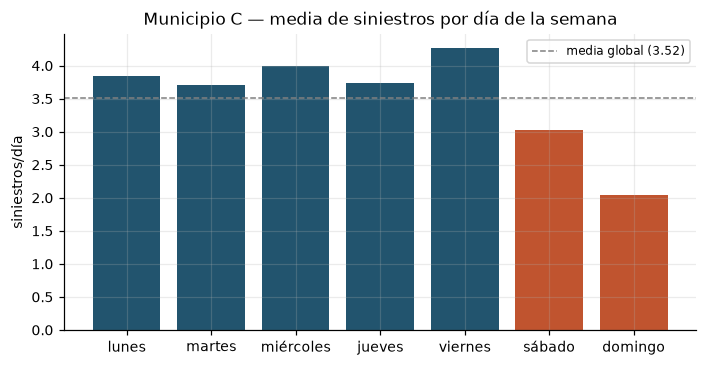

razón viernes/domingo: 2.09x


In [8]:
DIAS_SEMANA_ES = {0: "lunes", 1: "martes", 2: "miércoles", 3: "jueves",
                   4: "viernes", 5: "sábado", 6: "domingo"}
orden_semana = [DIAS_SEMANA_ES[i] for i in range(7)]

perfil_semanal = serie_c.groupby(serie_c.index.dayofweek.map(DIAS_SEMANA_ES)).mean().reindex(orden_semana)
perfil_semanal_tab = perfil_semanal.round(4).rename("media_siniestros_dia").reset_index().rename(columns={"index": "día"})
guardar_tabla(perfil_semanal_tab, "06_perfil_semanal")

fig, ax = plt.subplots(figsize=(6.5, 3.4))
colores = ["#22546e"] * 5 + ["#c0542f", "#c0542f"]
ax.bar(orden_semana, perfil_semanal.values, color=colores)
ax.axhline(serie_c.mean(), color="grey", ls="--", lw=1, label=f"media global ({serie_c.mean():.2f})")
ax.set_title(f"Municipio {MUNICIPIO_FOCO} — media de siniestros por día de la semana")
ax.set_ylabel("siniestros/día"); ax.legend(fontsize=8)
fig.tight_layout()
guardar_figura(fig, "fig2a_perfil_semanal_municipio_c")
plt.show()

print(f"razón viernes/domingo: {perfil_semanal['viernes'] / perfil_semanal['domingo']:.2f}x")

**Evidencia:** el orden semanal de Municipio C —viernes máximo, domingo mínimo— coincide con el
perfil del departamento entero (`resumen_diagnostico_datos.md` §4.4: viernes 25,74, domingo
16,06 sobre las ocho zonas). La razón viernes/domingo de este municipio es más marcada que la del
agregado departamental: el patrón semanal no se diluye al mirar una sola zona, más bien se acentúa
un poco.

### 2.3 Estacionalidad anual

Índice estacional mensual (cada mes dividido por la media de *su propio año*, el mismo método que
`diagnostico_datos.ipynb` usa en §3.1 para aislar la forma intraanual del nivel de cada año) y la
descomposición clásica (`statsmodels.tsa.seasonal.seasonal_decompose`, aditiva) de la serie diaria
con período 365, que separa tendencia y componente estacional anual de forma independiente del
índice hecho a mano.

[tabla]  experiments\diagnostico_datos_municipio\tablas\07_indice_estacional_mensual.csv


,mes,índice_estacional
0,1,0.7075
1,2,0.8242
2,3,0.9504
3,4,0.9881
4,5,1.0180
5,6,1.1050
6,7,1.0157
7,8,1.0940
8,9,1.0833
9,10,1.0354


[figura] experiments\diagnostico_datos_municipio\figuras\fig2b_estacionalidad_anual_municipio_c.png


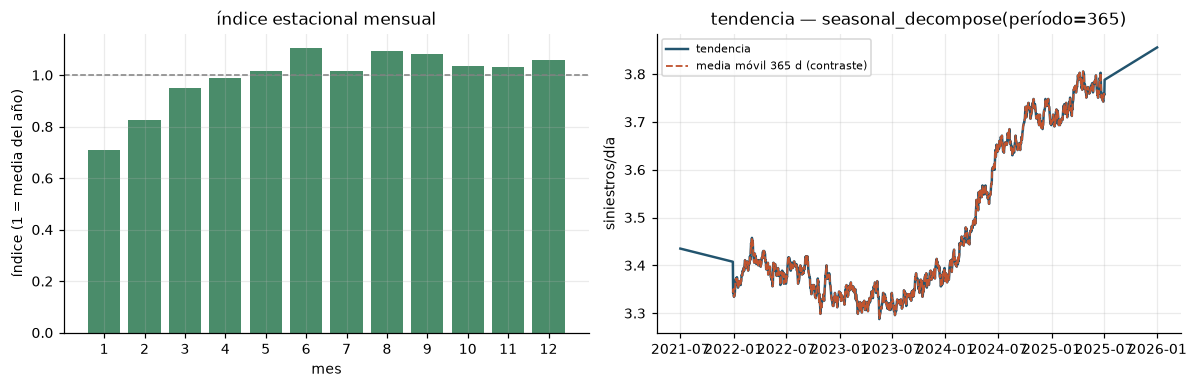

mes más bajo: 1 (índice 0.707) · mes más alto: 6 (índice 1.105)


In [9]:
tmp = serie_c.to_frame("n")
tmp["año"], tmp["mes"] = tmp.index.year, tmp.index.month
indice_mensual = (tmp["n"] / tmp.groupby("año")["n"].transform("mean")).groupby(tmp["mes"]).mean()
guardar_tabla(indice_mensual.round(4).rename("índice_estacional").reset_index(), "07_indice_estacional_mensual")

descomp = seasonal_decompose(serie_c, model="additive", period=365, extrapolate_trend="freq")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.6))
ax1.bar(indice_mensual.index, indice_mensual.values, color="#4a8c6a")
ax1.axhline(1.0, color="grey", ls="--", lw=1)
ax1.set_xticks(range(1, 13)); ax1.set_xlabel("mes"); ax1.set_ylabel("índice (1 = media del año)")
ax1.set_title("índice estacional mensual")

ax2.plot(descomp.trend.index, descomp.trend.values, color="#22546e", lw=1.6, label="tendencia")
ax2.plot(serie_c.index, serie_c.rolling(365, center=True).mean(), color="#c0542f", lw=1.2,
         ls="--", label="media móvil 365 d (contraste)")
ax2.set_title("tendencia — seasonal_decompose(período=365)")
ax2.set_ylabel("siniestros/día"); ax2.legend(fontsize=7)

fig.tight_layout()
guardar_figura(fig, "fig2b_estacionalidad_anual_municipio_c")
plt.show()

print(f"mes más bajo: {indice_mensual.idxmin()} (índice {indice_mensual.min():.3f}) · "
      f"mes más alto: {indice_mensual.idxmax()} (índice {indice_mensual.max():.3f})")

**Evidencia:** el índice estacional de Municipio C tiene su mínimo en **enero** (0,71) y su
máximo a mitad de año (junio, 1,11), sin el patrón de verano/invierno simple que uno podría
suponer a priori — enero y febrero (verano, vacaciones) son los meses más bajos del año, no los
más altos. La tendencia de `seasonal_decompose` coincide, como debía, con la lectura de la media
móvil de 365 días de la figura 1: confirma que la caída 2021-2023 y la recuperación 2024-2025 no
es un artefacto del suavizado elegido.

**Frase que estos datos NO sostienen:** «el verano tiene más siniestros por las vacaciones» —
enero y febrero son, de los doce meses, los de índice más bajo.

## 3. Autocorrelación (ACF/PACF) y dispersión por rezago

`diagnostico_datos.ipynb` (§5.2) mide la señal temporal contrastando la ACF observada contra una
**banda nula simulada** (siniestros de Poisson con la misma tasa media), porque a esa escala una
banda analítica no es válida — el supuesto de esa banda es ruido gaussiano, y un conteo bajo no lo
es. Acá, con una sola serie de conteo moderado (media ≈ 3,5/día, lejos de cero) y usando el ACF y
PACF estándar de `statsmodels`, la banda analítica de ±1,96/√n es una aproximación razonable
(consistente con el resultado empírico: la sección 4 confirma con ADF que la serie es estacionaria
en media, condición bajo la que esa banda es válida). Se calcula sobre la serie cruda y, después,
sobre el residuo de descontar el día de la semana y el feriado — el mismo desglose que
`diagnostico_datos.ipynb` usa para separar calendario de persistencia genuina.

[figura] experiments\diagnostico_datos_municipio\figuras\fig3a_acf_pacf_crudo_municipio_c.png


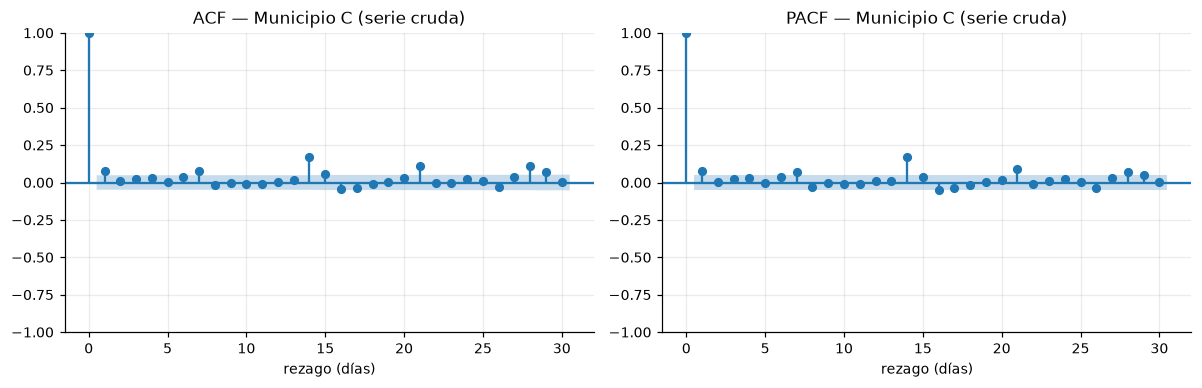

[tabla]  experiments\diagnostico_datos_municipio\tablas\08_acf_pacf_crudo.csv


,rezago,acf,pacf,fuera_de_banda_95
0,0,1.0000,NaN,True
1,1,0.0785,0.0786,True
2,2,0.0078,0.0017,False
3,3,0.0242,0.0237,False
4,4,0.0332,0.0297,False
5,5,0.0004,-0.0047,False
6,6,0.0397,0.0397,False
7,7,0.0764,0.0698,True
8,8,-0.0179,-0.0307,False
9,9,-0.0042,-0.0024,False


banda 95%: ±0.0483


In [10]:
NLAGS = 30
banda_95 = 1.96 / np.sqrt(len(serie_c))
vals = serie_c.to_numpy(float)

acf_cruda = acf(vals, nlags=NLAGS, fft=True)
pacf_cruda = pacf(vals, nlags=NLAGS)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
plot_acf(vals, lags=NLAGS, ax=axes[0], title=f"ACF — Municipio {MUNICIPIO_FOCO} (serie cruda)")
plot_pacf(vals, lags=NLAGS, ax=axes[1], method="ywm",
          title=f"PACF — Municipio {MUNICIPIO_FOCO} (serie cruda)")
for ax in axes:
    ax.set_xlabel("rezago (días)")
fig.tight_layout()
guardar_figura(fig, "fig3a_acf_pacf_crudo_municipio_c")
plt.show()

tabla_acf = pd.DataFrame({
    "rezago": range(NLAGS + 1), "acf": acf_cruda.round(4), "pacf": np.r_[np.nan, pacf_cruda[1:]].round(4),
})
tabla_acf["fuera_de_banda_95"] = tabla_acf["acf"].abs() > banda_95
guardar_tabla(tabla_acf, "08_acf_pacf_crudo")
print(f"banda 95%: ±{banda_95:.4f}")

### 3.1 Cuánto de la ACF cruda es calendario

Se resta a cada día la media de su grupo (día de la semana, con el feriado como grupo aparte —
igual construcción que `diagnostico_datos.ipynb` usa para su ACF de residuo) y se recalcula la
ACF sobre ese residuo.

[figura] experiments\diagnostico_datos_municipio\figuras\fig3b_acf_residuo_calendario_municipio_c.png


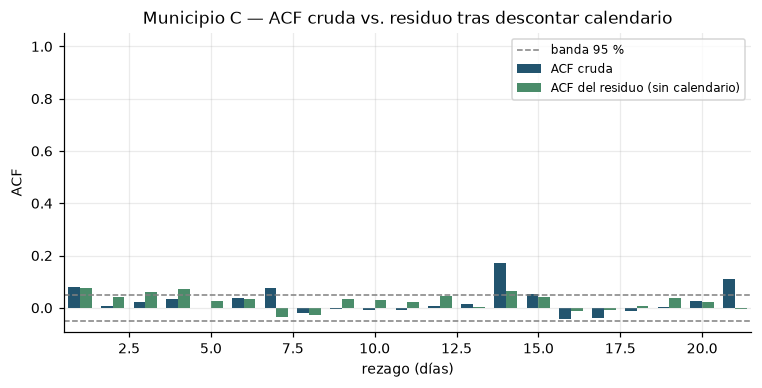

[tabla]  experiments\diagnostico_datos_municipio\tablas\09_acf_residuo_calendario.csv


,rezago,acf_cruda,acf_residuo,fuera_banda_cruda,fuera_banda_residuo
0,0,1.0000,1.0000,True,True
1,1,0.0785,0.0745,True,True
2,2,0.0078,0.0429,False,False
3,3,0.0242,0.0593,False,True
4,4,0.0332,0.0704,False,True
5,5,0.0004,0.0279,False,False
6,6,0.0397,0.0351,False,False
7,7,0.0764,-0.0329,True,False
8,8,-0.0179,-0.0280,False,False
9,9,-0.0042,0.0331,False,False


[tabla]  experiments\diagnostico_datos_municipio\tablas\10_ljung_box.csv


,rezago_max,lb_stat,lb_pvalue
0,7,25.306326,0.00067
1,14,74.903783,0.00000
2,30,140.510309,0.00000


In [11]:
fer = holidays.country_holidays("UY", years=range(DIAS[0].year, DIAS[-1].year + 1),
                                 categories=CATEGORIAS_FERIADO)
es_feriado = pd.Series(DIAS.date, index=DIAS).map(lambda d: d in fer)
grupo_cal = pd.Series(np.where(es_feriado, "feriado", DIAS.dayofweek.map(DIAS_SEMANA_ES)), index=DIAS)

medias_grupo = serie_c.groupby(grupo_cal).transform("mean")
residuo_cal = (serie_c - medias_grupo).to_numpy(float)
acf_residuo = acf(residuo_cal, nlags=NLAGS, fft=True)

fig, ax = plt.subplots(figsize=(7, 3.6))
x = np.arange(NLAGS + 1)
ax.bar(x - 0.18, acf_cruda, width=0.36, color="#22546e", label="ACF cruda")
ax.bar(x + 0.18, acf_residuo, width=0.36, color="#4a8c6a", label="ACF del residuo (sin calendario)")
ax.axhline(banda_95, color="grey", ls="--", lw=1)
ax.axhline(-banda_95, color="grey", ls="--", lw=1, label="banda 95 %")
ax.set_xlim(0.5, 21.5); ax.set_xlabel("rezago (días)"); ax.set_ylabel("ACF")
ax.set_title(f"Municipio {MUNICIPIO_FOCO} — ACF cruda vs. residuo tras descontar calendario")
ax.legend(fontsize=8)
fig.tight_layout()
guardar_figura(fig, "fig3b_acf_residuo_calendario_municipio_c")
plt.show()

tabla_residuo = pd.DataFrame({"rezago": range(NLAGS + 1), "acf_cruda": acf_cruda.round(4),
                               "acf_residuo": acf_residuo.round(4)})
tabla_residuo["fuera_banda_cruda"] = tabla_residuo["acf_cruda"].abs() > banda_95
tabla_residuo["fuera_banda_residuo"] = tabla_residuo["acf_residuo"].abs() > banda_95
guardar_tabla(tabla_residuo, "09_acf_residuo_calendario")

lb = acorr_ljungbox(vals, lags=[7, 14, 30], return_df=True).reset_index(names="rezago_max")
guardar_tabla(lb.round(6), "10_ljung_box")

**Evidencia:**

- En la ACF **cruda**, los rezagos múltiplos de 7 (7, 14, 21, 28) están fuera de la banda del
  95 %, con el máximo en el rezago 14 (≈0,17). Es la firma de un ciclo semanal, no
  necesariamente de memoria del proceso.
- Al descontar el día de la semana y el feriado, los rezagos 7, 21 y 28 **caen dentro de la
  banda**: esa parte de la ACF cruda era calendario. El rezago 1 **sobrevive** (∼0,07, fuera de
  banda) — hay persistencia genuina de un día para el otro que el calendario no explica,
  coherente con el hallazgo de `diagnostico_datos.ipynb` (§5.2) de que 5 de 8 municipios muestran
  esto mismo. El rezago 14 también queda algo fuera de banda en el residuo, más débil que en la
  serie cruda; con una sola serie y sin corrección por comparaciones múltiples no alcanza para
  afirmar un ciclo quincenal genuino, y se deja señalado en vez de interpretado.
- El test de Ljung-Box rechaza "no autocorrelación conjunta" con `p < 0,001` en los tres
  horizontes probados (7, 14 y 30 rezagos): hay estructura temporal estadísticamente detectable,
  aunque de magnitud pequeña en cada rezago individual.

**Inferencia del equipo:** coherente con la sección 5.2 del diagnóstico principal — el calendario
explica la mayor parte de lo que parece "estacionalidad semanal" en la ACF cruda, y lo que queda
después de descontarlo es pequeño pero real a rezago 1.

### 3.4 Dispersión por rezago (*scatter* de rezago)

Cada punto es un par (siniestros del día *t*, siniestros del día *t−k*), para k = 1, 7, 14 y 30.
Si hubiera memoria fuerte del proceso, la nube se vería alineada sobre la diagonal; el ruido de
Poisson de una serie de conteo bajo dispersa los puntos aun cuando la correlación subyacente
exista, así que la lectura tiene que apoyarse en el coeficiente y no sólo en la forma de la nube.

[figura] experiments\diagnostico_datos_municipio\figuras\fig4_dispersion_lags_municipio_c.png


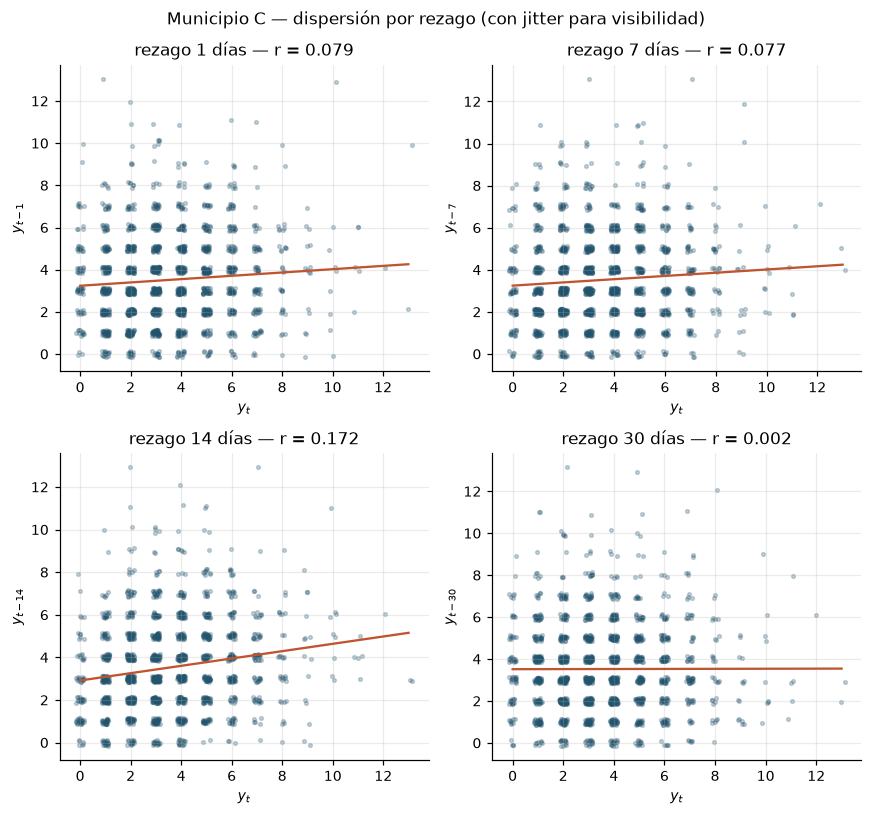

[tabla]  experiments\diagnostico_datos_municipio\tablas\11_dispersion_por_rezago.csv


,rezago,correlación_pearson
0,1,0.0785
1,7,0.0768
2,14,0.1724
3,30,0.0021


In [12]:
rezagos_scatter = [1, 7, 14, 30]
fig, axes = plt.subplots(2, 2, figsize=(8, 7.5))
filas_corr = []
rng = np.random.default_rng(42)
for ax, k in zip(axes.ravel(), rezagos_scatter):
    x, y = vals[:-k], vals[k:]
    jitter_x = x + rng.uniform(-0.15, 0.15, size=len(x))
    jitter_y = y + rng.uniform(-0.15, 0.15, size=len(y))
    r = np.corrcoef(x, y)[0, 1]
    filas_corr.append((k, round(r, 4)))
    ax.scatter(jitter_x, jitter_y, s=6, alpha=0.25, color="#22546e")
    m, b = np.polyfit(x, y, 1)
    xs = np.linspace(x.min(), x.max(), 50)
    ax.plot(xs, m * xs + b, color="#c0542f", lw=1.5)
    ax.set_title(f"rezago {k} días — r = {r:.3f}")
    ax.set_xlabel(f"$y_t$"); ax.set_ylabel(f"$y_{{t-{k}}}$")
fig.suptitle(f"Municipio {MUNICIPIO_FOCO} — dispersión por rezago (con jitter para visibilidad)")
fig.tight_layout()
guardar_figura(fig, "fig4_dispersion_lags_municipio_c")
plt.show()

guardar_tabla(pd.DataFrame(filas_corr, columns=["rezago", "correlación_pearson"]), "11_dispersion_por_rezago")

**Evidencia:** el coeficiente de correlación de cada panel es chico (todos por debajo de 0,2) y
decae del rezago 1 al 7; el jitter añadido a los puntos es sólo para separarlos visualmente —dado
que el objetivo es un entero de rango 0–13—, no altera la correlación, que se calcula sobre los
valores originales. Es la misma conclusión que la ACF: hay señal, es pequeña, y no se ve una nube
claramente alineada en ningún panel.

## 4. ¿Corresponde diferenciar o transformar el objetivo?

La pregunta tiene dos partes que conviene separar: **(a)** ¿hay una tendencia/raíz unitaria que
justifique diferenciar en nivel?, y **(b)** ¿la varianza escala con el nivel de forma que
justifique estabilizarla con logaritmo o Box-Cox? Las dos se responden con evidencia, no por
convención de manual de series temporales — la serie es un conteo bajo con ceros (4,80 % de los
días), y las transformaciones clásicas de Box-Jenkins se pensaron para series continuas.

### 4.1 Estacionariedad: ADF y KPSS

In [13]:
adf_stat, adf_p, *_ = adfuller(vals, autolag="AIC")
kpss_stat, kpss_p, *_ = kpss(vals, regression="c", nlags="auto")

estacionariedad = pd.DataFrame(
    [("ADF", "H0: hay raíz unitaria (no estacionaria)", round(adf_stat, 4), f"{adf_p:.2e}",
      "rechaza H0 (estacionaria)" if adf_p < 0.05 else "no rechaza H0"),
     ("KPSS", "H0: la serie es estacionaria", round(kpss_stat, 4),
      f"≤ 0.01" if kpss_p <= 0.01 else f"{kpss_p:.4f}",
      "rechaza H0 (no estacionaria)" if kpss_p < 0.05 else "no rechaza H0")],
    columns=["prueba", "hipótesis nula", "estadístico", "p-valor", "resultado (α=0,05)"],
)
guardar_tabla(estacionariedad, "12_estacionariedad_adf_kpss")

[tabla]  experiments\diagnostico_datos_municipio\tablas\12_estacionariedad_adf_kpss.csv


C:\Users\Samuca\AppData\Local\Temp\ipykernel_20716\533698117.py:2: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(vals, regression="c", nlags="auto")


,prueba,hipótesis nula,estadístico,p-valor,"resultado (α=0,05)"
0,ADF,H0: hay raíz unitaria (no estacionaria),-7.0716,4.92e-10,rechaza H0 (estacionaria)
1,KPSS,H0: la serie es estacionaria,1.2915,≤ 0.01,rechaza H0 (no estacionaria)


**Evidencia — y una tensión que hay que declarar, no esconder:** el ADF **rechaza** la raíz
unitaria con margen amplio (`p` del orden de 10⁻¹⁰): sobre esta prueba, la serie es estacionaria
en media. El KPSS, en cambio, **rechaza** la estacionariedad (`p ≤ 0,01`). Las dos prueban
hipótesis nulas opuestas y a veces discrepan quejándose de cosas distintas: el ADF es más
sensible a una raíz unitaria genuina, el KPSS reacciona también a un **nivel que cambia
lentamente** sin llegar a una raíz unitaria — que es exactamente lo que muestra la media anual no
monótona de la figura 1 (§2.1). **Lectura del equipo:** la combinación es compatible con una
serie estacionaria alrededor de un nivel que deriva despacio entre años, no con una tendencia
determinística fuerte ni con una caminata aleatoria. No se puede afirmar sin matices que "la serie
es estacionaria": lo que dicen las dos pruebas juntas es que no hay raíz unitaria, pero tampoco
hay un nivel constante en sentido estricto.

### 4.2 ¿Diferenciar ayuda o sobrecorrige?

In [14]:
diff1 = np.diff(vals, n=1)
diff7 = vals[7:] - vals[:-7]

comparacion_diff = pd.DataFrame({
    "serie": ["cruda", "diferenciada (d=1)", "diferenciada estacional (D=1, s=7)"],
    "acf_rezago_1": [round(acf(s, nlags=1, fft=True)[1], 4) for s in (vals, diff1, diff7)],
    "acf_rezago_2": [round(acf(s, nlags=2, fft=True)[2], 4) for s in (vals, diff1, diff7)],
    "acf_rezago_7": [round(acf(s, nlags=7, fft=True)[7], 4) for s in (vals, diff1, diff7)],
    "varianza": [round(np.var(s), 4) for s in (vals, diff1, diff7)],
})
guardar_tabla(comparacion_diff, "13_efecto_diferenciacion")

[tabla]  experiments\diagnostico_datos_municipio\tablas\13_efecto_diferenciacion.csv


,serie,acf_rezago_1,acf_rezago_2,acf_rezago_7,varianza
0,cruda,0.0785,0.0078,0.0764,4.4297
1,diferenciada (d=1),-0.4621,-0.0460,0.0708,8.1661
2,"diferenciada estacional (D=1, s=7)",0.0722,0.0091,-0.5481,8.1740


**Evidencia:** diferenciar en nivel (d=1) **no reduce** la autocorrelación — la vuelve fuertemente
**negativa** en el rezago 1 (≈ −0,46). Es la firma clásica de sobrediferenciación: se le resta a
la serie más estructura de la que tenía, y se introduce una correlación negativa artificial que no
estaba en los datos. La diferenciación estacional (s=7) no cambia sustancialmente el panorama frente
a la serie cruda. **Ninguna de las dos ayuda**, y la de d=1 activamente perjudica.

**Inferencia del equipo:** consistente con el ADF de 4.1 — si no hay raíz unitaria, diferenciar no
tiene un problema de no-estacionariedad que resolver, y el costo (sobrediferenciación) queda a la
vista en la tabla.

### 4.3 ¿La varianza escala con el nivel? Log, Box-Cox y la alternativa de conteo

[figura] experiments\diagnostico_datos_municipio\figuras\fig5_transformaciones_municipio_c.png


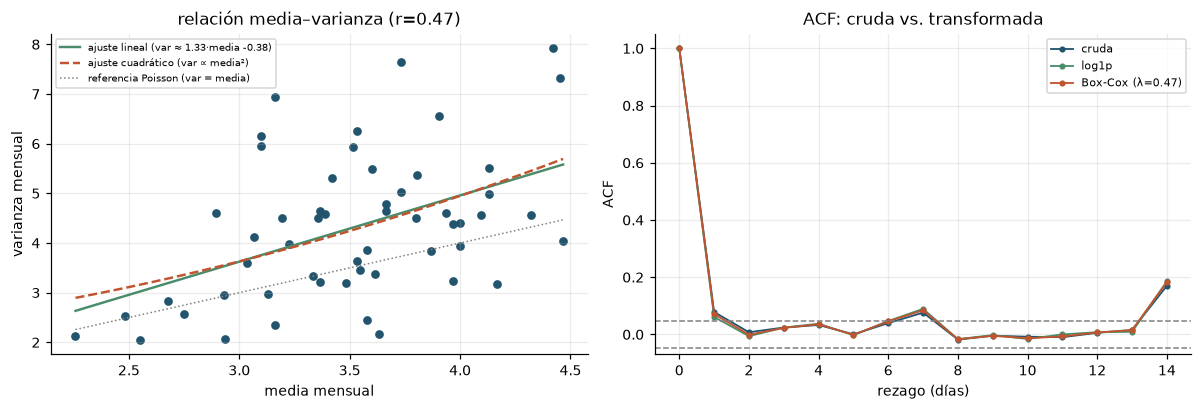

[tabla]  experiments\diagnostico_datos_municipio\tablas\14_diagnostico_transformacion.csv


,indicador,valor
0,"ajuste lineal var~media (pendiente, intercepto)","1.334, -0.378"
1,"ajuste cuadrático var~media² (pendiente, inter...","0.188, 1.935"
2,correlación media–varianza mensual,0.4681
3,λ de Box-Cox estimado por máxima verosimilitud...,0.4733
4,λ=0 equivaldría a,logaritmo
5,"λ=0,5 equivaldría a",raíz cuadrada (transformación de Anscombe para...
6,λ=1 equivaldría a,sin transformar


In [15]:
tmp = serie_c.to_frame("n")
tmp["mes"] = tmp.index.to_period("M")
por_mes = tmp.groupby("mes")["n"].agg(["mean", "var"]).rename(columns={"mean": "media", "var": "varianza"})

coef_lineal = np.polyfit(por_mes["media"], por_mes["varianza"], 1)
coef_cuadratico = np.polyfit(por_mes["media"] ** 2, por_mes["varianza"], 1)
r_lineal = np.corrcoef(por_mes["media"], por_mes["varianza"])[0, 1]

lam_boxcox = sps.boxcox_normmax(vals + 1, method="mle")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.8))

ax1.scatter(por_mes["media"], por_mes["varianza"], s=22, color="#22546e")
xs = np.linspace(por_mes["media"].min(), por_mes["media"].max(), 50)
ax1.plot(xs, np.polyval(coef_lineal, xs), color="#4a8c6a", lw=1.6,
          label=f"ajuste lineal (var ≈ {coef_lineal[0]:.2f}·media {coef_lineal[1]:+.2f})")
ax1.plot(xs, np.polyval(coef_cuadratico, xs ** 2), color="#c0542f", lw=1.6, ls="--",
          label="ajuste cuadrático (var ∝ media²)")
ax1.plot(xs, xs, color="grey", lw=1, ls=":", label="referencia Poisson (var = media)")
ax1.set_xlabel("media mensual"); ax1.set_ylabel("varianza mensual")
ax1.set_title(f"relación media–varianza (r={r_lineal:.2f})"); ax1.legend(fontsize=6.5)

for nombre, serie_x, color in [("cruda", vals, "#22546e"), ("log1p", np.log1p(vals), "#4a8c6a"),
                                 (f"Box-Cox (λ={lam_boxcox:.2f})", sps.boxcox(vals + 1, lam_boxcox), "#c0542f")]:
    a = acf(serie_x, nlags=14, fft=True)
    ax2.plot(range(15), a, marker="o", ms=3, lw=1.2, color=color, label=nombre)
ax2.axhline(banda_95, color="grey", ls="--", lw=1); ax2.axhline(-banda_95, color="grey", ls="--", lw=1)
ax2.set_xlabel("rezago (días)"); ax2.set_ylabel("ACF"); ax2.set_title("ACF: cruda vs. transformada")
ax2.legend(fontsize=7)

fig.tight_layout()
guardar_figura(fig, "fig5_transformaciones_municipio_c")
plt.show()

transformaciones = pd.DataFrame(
    [("ajuste lineal var~media (pendiente, intercepto)", f"{coef_lineal[0]:.3f}, {coef_lineal[1]:.3f}"),
     ("ajuste cuadrático var~media² (pendiente, intercepto)", f"{coef_cuadratico[0]:.3f}, {coef_cuadratico[1]:.3f}"),
     ("correlación media–varianza mensual", round(r_lineal, 4)),
     ("λ de Box-Cox estimado por máxima verosimilitud (sobre serie+1)", round(float(lam_boxcox), 4)),
     ("λ=0 equivaldría a", "logaritmo"),
     ("λ=0,5 equivaldría a", "raíz cuadrada (transformación de Anscombe para Poisson)"),
     ("λ=1 equivaldría a", "sin transformar")],
    columns=["indicador", "valor"],
)
guardar_tabla(transformaciones, "14_diagnostico_transformacion")

**Evidencia:**

- La relación entre la media y la varianza mensuales se ajusta mejor con una recta que pasa cerca
  del origen (`var ≈ 1,33·media − 0,38`) que con una parábola forzada por el origen: es el patrón
  de un proceso de conteo con sobredispersión moderada y constante (tipo cuasi-Poisson, con razón
  de dispersión ≈ 1,3, coherente con el índice de dispersión de toda la serie, 1,26) — **no** el
  patrón de varianza proporcional al cuadrado de la media que un logaritmo está diseñado para
  corregir.
- El λ de Box-Cox estimado por máxima verosimilitud da **≈ 0,47** — cerca de 0,5, que es
  exactamente la **raíz cuadrada**, la transformación estabilizadora de varianza clásica para
  datos de conteo tipo Poisson (transformación de Anscombe), no el logaritmo (λ=0). El propio
  procedimiento de Box-Cox, aplicado sobre estos datos, apunta lejos del logaritmo.
- Con **4,80 % de días en cero**, ni el logaritmo ni Box-Cox están definidos sobre la serie
  original: los dos exigen desplazarla (`+1`), una decisión adicional que no hace falta si no se
  transforma.
- En la ACF a 14 rezagos, ni `log1p` ni Box-Cox cambian la estructura de forma apreciable frente a
  la serie cruda (panel derecho de la figura): la autocorrelación pequeña que hay no es un
  artefacto de escala que una transformación monótona pueda destapar o esconder.

**Inferencia del equipo — la respuesta a la pregunta del enunciado:** con esta evidencia, **no
corresponde aplicar diferenciación ni una transformación logarítmica o Box-Cox clásica al
objetivo**. Los tres argumentos se sostienen entre sí: (1) el ADF no encuentra raíz unitaria y
diferenciar sobrecorrige (§4.2); (2) la relación varianza-media es lineal, no cuadrática, así que
el supuesto detrás del logaritmo no se cumple; y (3) el propio λ de Box-Cox estimado cae cerca de
la raíz cuadrada, la transformación *nativa* de un proceso de conteo, y no cambia la estructura de
autocorrelación de todos modos. Esto es consistente con la decisión que ya toma
`resumen_diagnostico_datos.md` (§5.1): tratar el objetivo como una variable de **conteo** (familia
Poisson/binomial negativa, con desvianza de Poisson como métrica) en lugar de forzarlo a un
esquema Box-Jenkins pensado para series continuas. Si en el notebook de modelado se necesitara
igualmente estabilizar varianza por algún requisito de un método específico, la evidencia acá
respalda la **raíz cuadrada** antes que el logaritmo — no ambas cosas a la vez.

**Frases que estos datos NO sostienen:**

- ❌ «La serie no es estacionaria y hay que diferenciarla.» → El ADF rechaza la raíz unitaria con
  amplio margen, y diferenciar empeora la ACF (sobrediferenciación).
- ❌ «Hace falta un logaritmo para estabilizar la varianza.» → La relación media-varianza es
  lineal, no cuadrática; el λ de Box-Cox estimado (≈0,47) está lejos de 0 (logaritmo) y cerca de
  0,5 (raíz cuadrada).
- ❌ «La serie es estacionaria», sin matices. → El KPSS rechaza esa hipótesis; hay una deriva de
  nivel lenta entre años que el ADF no capta porque no es una raíz unitaria.

## 5. Limitaciones y lo que este notebook NO responde

| Limitación | Consecuencia |
| --- | --- |
| **Un solo municipio.** No hay garantía de que la conclusión de la sección 4 valga igual para los otros siete; se eligió C por ser el de más soporte, no por ser representativo. | Antes de fijar la transformación del objetivo para el modelo final, conviene repetir al menos el diagnóstico de estacionariedad (§4.1) en 2-3 municipios de actividad distinta. |
| **La banda de la ACF/PACF es analítica (±1,96/√n)**, no simulada como en `diagnostico_datos.ipynb`. Es una aproximación razonable porque la media diaria de esta serie (≈3,5) está lejos de cero, pero sigue siendo una aproximación asintótica sobre una variable discreta. | No cambia las conclusiones (los rezagos señalados también superan las bandas simuladas del notebook principal), pero no hay que citar el valor exacto de la banda como si fuera exacto. |
| **El rezago 14 en el residuo de calendario** (§3.1) queda señalado, no explicado: con una sola prueba y sin corregir por comparaciones múltiples, no alcanza para afirmar un ciclo quincenal. | Declarar como observación, no como hallazgo confirmado. |
| **No se evaluó el clima** en este notebook (no hace falta para tendencia/estacionalidad/ACF del objetivo). | La relación entre clima y la serie de Municipio C está fuera de este alcance; ver `resumen_diagnostico_datos.md` §5.3 para el aporte del clima al panel completo. |
| **La recomendación de no transformar es sobre el objetivo tal como se define hoy** (conteo diario por municipio). Si el objetivo cambiara de definición (por ejemplo, una tasa continua), la conclusión de la sección 4 no se traslada automáticamente. | Releer la sección 4 si cambia la definición del objetivo. |

## 6. Índice de artefactos

In [16]:
import os
filas = []
for carpeta, tipo in [(DIR_TABLAS, "tabla"), (DIR_FIGURAS, "figura")]:
    for archivo in sorted(carpeta.iterdir()):
        filas.append((tipo, str(archivo.relative_to(RAIZ)), f"{archivo.stat().st_size / 1e3:.1f} kB"))
indice = pd.DataFrame(filas, columns=["tipo", "archivo", "tamaño"])
guardar_tabla(indice, "15_artefactos")
print(f"\ntotal: {(indice['tipo'] == 'tabla').sum()} tablas, {(indice['tipo'] == 'figura').sum()} figuras")

[tabla]  experiments\diagnostico_datos_municipio\tablas\15_artefactos.csv


,tipo,archivo,tamaño
0,tabla,experiments\diagnostico_datos_municipio\tablas...,0.3 kB
1,tabla,experiments\diagnostico_datos_municipio\tablas...,0.2 kB
2,tabla,experiments\diagnostico_datos_municipio\tablas...,0.2 kB
3,tabla,experiments\diagnostico_datos_municipio\tablas...,0.1 kB
4,tabla,experiments\diagnostico_datos_municipio\tablas...,0.3 kB
5,tabla,experiments\diagnostico_datos_municipio\tablas...,0.3 kB
6,tabla,experiments\diagnostico_datos_municipio\tablas...,0.1 kB
7,tabla,experiments\diagnostico_datos_municipio\tablas...,0.1 kB
8,tabla,experiments\diagnostico_datos_municipio\tablas...,0.1 kB
9,tabla,experiments\diagnostico_datos_municipio\tablas...,0.8 kB



total: 17 tablas, 7 figuras


| Eje | Tablas |
| --- | --- |
| Trazabilidad | `00_procedencia`, `00b_entorno` |
| Datos | `01_recorte_alcance`, `02_asignacion_municipios`, `03_verificacion_cruzada`, `04_resumen_serie_municipio_c` |
| Tendencia y estacionalidad | `05_tendencia_anual`, `06_perfil_semanal`, `07_indice_estacional_mensual` |
| ACF/PACF y dispersión | `08_acf_pacf_crudo`, `09_acf_residuo_calendario`, `10_ljung_box`, `11_dispersion_por_rezago` |
| Transformaciones | `12_estacionariedad_adf_kpss`, `13_efecto_diferenciacion`, `14_diagnostico_transformacion` |
| Índice | `15_artefactos` |

**Figuras:**

| Figura | Qué muestra | Sección |
| --- | --- | --- |
| `fig1_tendencia_municipio_c.png` | Serie diaria con medias móviles de 30/90 días y media anual | 2.1 |
| `fig2a_perfil_semanal_municipio_c.png` | Media de siniestros por día de la semana | 2.2 |
| `fig2b_estacionalidad_anual_municipio_c.png` | Índice estacional mensual y tendencia de `seasonal_decompose` | 2.3 |
| `fig3a_acf_pacf_crudo_municipio_c.png` | ACF y PACF de la serie cruda (statsmodels) | 3 |
| `fig3b_acf_residuo_calendario_municipio_c.png` | ACF cruda vs. ACF del residuo tras descontar calendario | 3.1 |
| `fig4_dispersion_lags_municipio_c.png` | Dispersión de $y_t$ contra $y_{t-k}$ para k=1,7,14,30 | 3.4 |
| `fig5_transformaciones_municipio_c.png` | Relación media-varianza mensual y ACF cruda vs. log1p vs. Box-Cox | 4.3 |